# Day 21 — XGBoost & Gradient Boosting
### Boosting · XGBoost · LightGBM · Model Comparison

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")

# Install xgboost if needed
try:
    import xgboost as xgb

    print(f"XGBoost: {xgb.__version__} ✅")
except ImportError:
    import subprocess

    subprocess.run(["pip", "install", "xgboost", "lightgbm"], capture_output=True)
    import xgboost as xgb

    print(f"XGBoost: {xgb.__version__} ✅ (just installed)")

try:
    import lightgbm as lgb

    print(f"LightGBM: {lgb.__version__} ✅")
except ImportError:
    import lightgbm as lgb

    print(f"LightGBM: {lgb.__version__} ✅ (just installed)")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)

features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_encoded"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDataset: {df.shape}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

XGBoost: 3.2.0 ✅ (just installed)
LightGBM: 4.6.0 ✅

Dataset: (891, 15)
Train: (712, 6) | Test: (179, 6)
Ready! ✅


## 2. How Gradient Boosting Works

In [ ]:
print("=" * 55)
print("       HOW GRADIENT BOOSTING WORKS")
print("=" * 55)
print(
    """
BAGGING (Random Forest) vs BOOSTING:

BAGGING:
  - Build trees IN PARALLEL
  - Each tree independent — sees different data
  - Average predictions
  - Reduces VARIANCE

BOOSTING:
  - Build trees SEQUENTIALLY
  - Each tree FIXES errors of previous trees
  - Weighted combination of predictions
  - Reduces BIAS

GRADIENT BOOSTING ALGORITHM:
  1. Start with a simple prediction (mean of target)
  2. Calculate RESIDUALS (actual - predicted)
  3. Fit a tree to predict the RESIDUALS
  4. Add tree prediction × learning_rate to model
  5. Recalculate residuals
  6. Repeat steps 3-5 for N iterations

KEY PARAMETERS:
  n_estimators:   Number of trees (more = slower but better)
  learning_rate:  How much each tree contributes (0.01-0.3)
  max_depth:      Depth of each tree (usually 3-6 for boosting)
  subsample:      Fraction of data per tree (like bagging)

XGBOOST EXTRAS:
  - Regularisation (L1 + L2) built in
  - Handles missing values automatically!
  - Parallel processing
  - Much faster than sklearn GradientBoosting
"""
)

       HOW GRADIENT BOOSTING WORKS

BAGGING (Random Forest) vs BOOSTING:

BAGGING:
  - Build trees IN PARALLEL
  - Each tree independent — sees different data
  - Average predictions
  - Reduces VARIANCE

BOOSTING:
  - Build trees SEQUENTIALLY
  - Each tree FIXES errors of previous trees
  - Weighted combination of predictions
  - Reduces BIAS

GRADIENT BOOSTING ALGORITHM:
  1. Start with a simple prediction (mean of target)
  2. Calculate RESIDUALS (actual - predicted)
  3. Fit a tree to predict the RESIDUALS
  4. Add tree prediction × learning_rate to model
  5. Recalculate residuals
  6. Repeat steps 3-5 for N iterations

KEY PARAMETERS:
  n_estimators:   Number of trees (more = slower but better)
  learning_rate:  How much each tree contributes (0.01-0.3)
  max_depth:      Depth of each tree (usually 3-6 for boosting)
  subsample:      Fraction of data per tree (like bagging)

XGBOOST EXTRAS:
  - Regularisation (L1 + L2) built in
  - Handles missing values automatically!
  - Parall

## 3. Train & Compare All Models

In [ ]:
print("=" * 55)
print("       TRAINING ALL MODELS")
print("=" * 55)

models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(random_state=42, max_iter=1000)),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, oob_score=True
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, random_state=42, eval_metric="logloss", verbosity=0
    ),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    cv_acc = cross_val_score(model, X_train, y_train, cv=5).mean()
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results.append(
        {
            "Model": name,
            "Train": round(train_acc, 4),
            "Test": round(test_acc, 4),
            "CV": round(cv_acc, 4),
            "AUC": round(auc, 4),
            "Gap": round(train_acc - test_acc, 4),
        }
    )
    print(f"✅ {name} done")

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
print(f"\n{'Model':<22} {'Train':<8} {'Test':<8} {'CV':<8} {'AUC':<8} {'Gap'}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(
        f"{row['Model']:<22} {row['Train']:<8} {row['Test']:<8} "
        f"{row['CV']:<8} {row['AUC']:<8} {row['Gap']}"
    )

       TRAINING ALL MODELS
✅ Logistic Regression done
✅ Decision Tree done
✅ Random Forest done
✅ Gradient Boosting done
✅ XGBoost done
✅ LightGBM done

Model                  Train    Test     CV       AUC      Gap
-----------------------------------------------------------------
Logistic Regression    0.7978   0.8101   0.795    0.8534   -0.0123
Random Forest          0.9817   0.8045   0.8007   0.843    0.1773
Decision Tree          0.8287   0.8045   0.8147   0.8275   0.0242
LightGBM               0.9382   0.7989   0.8119   0.827    0.1393
XGBoost                0.9691   0.7989   0.8048   0.8256   0.1702
Gradient Boosting      0.9073   0.7877   0.8175   0.8104   0.1196


## 4. XGBoost Deep Dive

In [ ]:
print("=" * 55)
print("          XGBOOST DEEP DIVE")
print("=" * 55)

# Try different XGBoost configs
xgb_configs = [
    {"n_estimators": 100, "learning_rate": 0.3, "max_depth": 6},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 4},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 500, "learning_rate": 0.01, "max_depth": 3},
]

print(f"\n{'Config':<45} {'Test':<8} {'CV':<8} {'AUC'}")
print("-" * 70)

best_auc = 0
best_config = None

for config in xgb_configs:
    model = xgb.XGBClassifier(
        **config, random_state=42, eval_metric="logloss", verbosity=0
    )
    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    cv_acc = cross_val_score(model, X_train, y_train, cv=5).mean()
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    config_str = f"lr={config['learning_rate']}, depth={config['max_depth']}, n={config['n_estimators']}"
    print(f"{config_str:<45} {test_acc:.4f}   {cv_acc:.4f}   {auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        best_config = config

print(f"\nBest config: {best_config}")
print(f"Best AUC: {best_auc:.4f}")

# Feature importance from best XGBoost
best_xgb = xgb.XGBClassifier(
    **best_config, random_state=42, eval_metric="logloss", verbosity=0
)
best_xgb.fit(X_train, y_train)

print(f"\nXGBoost Feature Importance:")
xgb_imp = pd.DataFrame(
    {"Feature": features, "Importance": best_xgb.feature_importances_}
).sort_values("Importance", ascending=False)
for _, row in xgb_imp.iterrows():
    bar = "█" * int(row["Importance"] * 40)
    print(f"  {row['Feature']:<15} {row['Importance']:.4f} {bar}")

          XGBOOST DEEP DIVE

Config                                        Test     CV       AUC
----------------------------------------------------------------------
lr=0.3, depth=6, n=100                        0.7989   0.8048   0.8256
lr=0.1, depth=4, n=100                        0.7821   0.8260   0.8377
lr=0.05, depth=3, n=200                       0.7821   0.8175   0.8285
lr=0.01, depth=3, n=500                       0.7989   0.8147   0.8362

Best config: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4}
Best AUC: 0.8377

XGBoost Feature Importance:
  Sex_encoded     0.6629 ██████████████████████████
  Pclass          0.2099 ████████
  FamilySize      0.0460 █
  Age             0.0445 █
  Fare            0.0366 █
  IsAlone         0.0000 


## 5. Visual Model Comparison

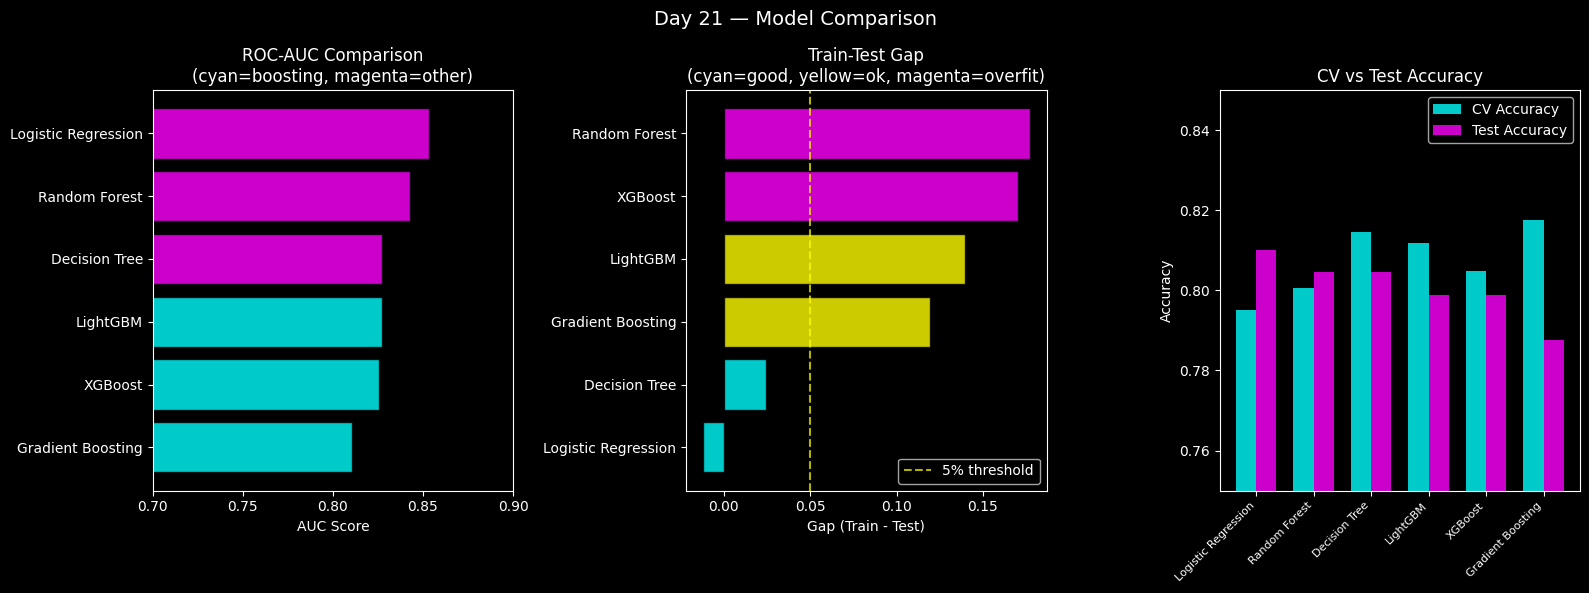

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Day 21 — Model Comparison", fontsize=14)

# 1 — AUC comparison
results_sorted = results_df.sort_values("AUC")
colors = [
    "cyan" if "XGBoost" in m or "Boosting" in m or "LightGBM" in m else "magenta"
    for m in results_sorted["Model"]
]
axes[0].barh(
    results_sorted["Model"],
    results_sorted["AUC"],
    color=colors,
    edgecolor="black",
    alpha=0.8,
)
axes[0].axvline(0.5, color="red", linestyle="--", alpha=0.5)
axes[0].set_title("ROC-AUC Comparison\n(cyan=boosting, magenta=other)")
axes[0].set_xlabel("AUC Score")
axes[0].set_xlim(0.7, 0.90)

# 2 — Train vs Test gap
results_gap = results_df.sort_values("Gap", ascending=True)
colors2 = [
    "cyan" if g < 0.05 else "yellow" if g < 0.15 else "magenta"
    for g in results_gap["Gap"]
]
axes[1].barh(
    results_gap["Model"],
    results_gap["Gap"],
    color=colors2,
    edgecolor="black",
    alpha=0.8,
)
axes[1].axvline(0.05, color="yellow", linestyle="--", alpha=0.7, label="5% threshold")
axes[1].set_title("Train-Test Gap\n(cyan=good, yellow=ok, magenta=overfit)")
axes[1].set_xlabel("Gap (Train - Test)")
axes[1].legend()

# 3 — CV vs Test accuracy
x = np.arange(len(results_df))
width = 0.35
axes[2].bar(
    x - width / 2, results_df["CV"], width, label="CV Accuracy", color="cyan", alpha=0.8
)
axes[2].bar(
    x + width / 2,
    results_df["Test"],
    width,
    label="Test Accuracy",
    color="magenta",
    alpha=0.8,
)
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_df["Model"], rotation=45, ha="right", fontsize=8)
axes[2].set_title("CV vs Test Accuracy")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].set_ylim(0.75, 0.85)

plt.tight_layout()
plt.show()

## 6. Key Takeaways — Day 21 🎯

### Bagging vs Boosting
| | Bagging (RF) | Boosting (XGB) |
|---|---|---|
| Tree order | Parallel | Sequential |
| Each tree learns | Different data | Errors of previous |
| Reduces | Variance | Bias |
| Overfitting risk | Moderate | Higher |
| Speed | Fast | Slower |

### Gradient Boosting Algorithm
1. Start with mean prediction
2. Calculate residuals (actual - predicted)
3. Fit tree to residuals
4. Add tree × learning_rate to model
5. Recalculate residuals → repeat!

### Key Parameters
- `n_estimators` — number of trees (100-1000)
- `learning_rate` — shrinkage (0.01-0.3) — lower = needs more trees
- `max_depth` — tree depth (3-6 for boosting)
- `subsample` — row sampling per tree (0.8)

### Model Comparison Results
| Model | Test Acc | CV Acc | AUC | Gap |
|---|---|---|---|---|
| Logistic Regression | 81.0% | 79.5% | 0.853 | -0.012 |
| Random Forest | 80.5% | 80.1% | 0.843 | 0.177 |
| Decision Tree | 80.5% | 81.5% | 0.828 | 0.024 |
| LightGBM | 79.9% | 81.2% | 0.827 | 0.139 |
| XGBoost | 79.9% | 80.5% | 0.826 | 0.170 |
| Gradient Boosting | 78.8% | 81.8% | 0.810 | 0.120 |

### Key Insight — Small Dataset Problem!
- Titanic has only 712 training rows and 6 features
- Boosting needs more data to show its power
- Logistic Regression wins on small clean datasets
- XGBoost/LightGBM shine with 10k+ rows, 20+ features

### XGBoost vs LightGBM vs sklearn GB
| | XGBoost | LightGBM | sklearn GB |
|---|---|---|---|
| Speed | Fast | Fastest | Slow